In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from analysis_by_plot import draw_floorplan
from utils import spl

In [2]:
model_names = 'CXonly', 'MB2ONbilateral'
ls_color = 'rb'
n_model = len(model_names)

n_trial = 20
ls_var = 'x', 'y', 'f'

In [3]:
record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/'
experiment_id = 'point-goal-noise-paper'

data_dir = os.path.join(record_dir, experiment_id, 'sim_20250109_125049_Pomaria_1_int') # noise 5%
alldata = {}
for model_name in model_names:
    alldata[model_name] = {'steer': []}
    for var in ls_var:
        alldata[model_name][var] = []

    for trial in range(n_trial):
        data_name = 'Freight_{}_trial_{}_record.npz'.format(model_name, trial)
        data = np.load(os.path.join(data_dir, data_name), allow_pickle=True)
        alldata[model_name]['steer'].append(data['extra'][()]['steer_mode'])
        for var in ls_var:
            alldata[model_name][var].append(data[var])

scene_name = data['scene_name']
pos_start_goal = np.transpose([data['pos_start'][:2], data['pos_goal'][:2]])

allbiasdata = {0: alldata}
bias_level = -0.5, -0.3, -0.1, 0, 0.1, 0.3, 0.5

In [4]:
allbiasdata.keys()

dict_keys([0])

In [5]:
record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/'
experiment_id = 'point-goal-bias-paper'



for trial_id, bias in zip(np.sort(os.listdir(os.path.join(record_dir, experiment_id)))[::-1], [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5]):
    data_dir = os.path.join(record_dir, experiment_id, trial_id)
    
    alldata = {}
    allbiasdata[bias] = alldata
    for model_name in model_names:
        alldata[model_name] = {'steer': []}
        for var in ls_var:
            alldata[model_name][var] = []

        for trial in range(n_trial):
            data_name = 'Freight_{}_trial_{}_record.npz'.format(model_name, trial)
            data = np.load(os.path.join(data_dir, data_name), allow_pickle=True)
            alldata[model_name]['steer'].append(data['extra'][()]['steer_mode'])
            for var in ls_var:
                alldata[model_name][var].append(data[var])

    scene_name = data['scene_name']
    pos_start_goal = np.transpose([data['pos_start'][:2], data['pos_goal'][:2]])

In [6]:
shortest_dist = np.linalg.norm(pos_start_goal[:, -1] - pos_start_goal[:, 0]) 

Text(0.5, 1.0, 'Pomaria_1_int')

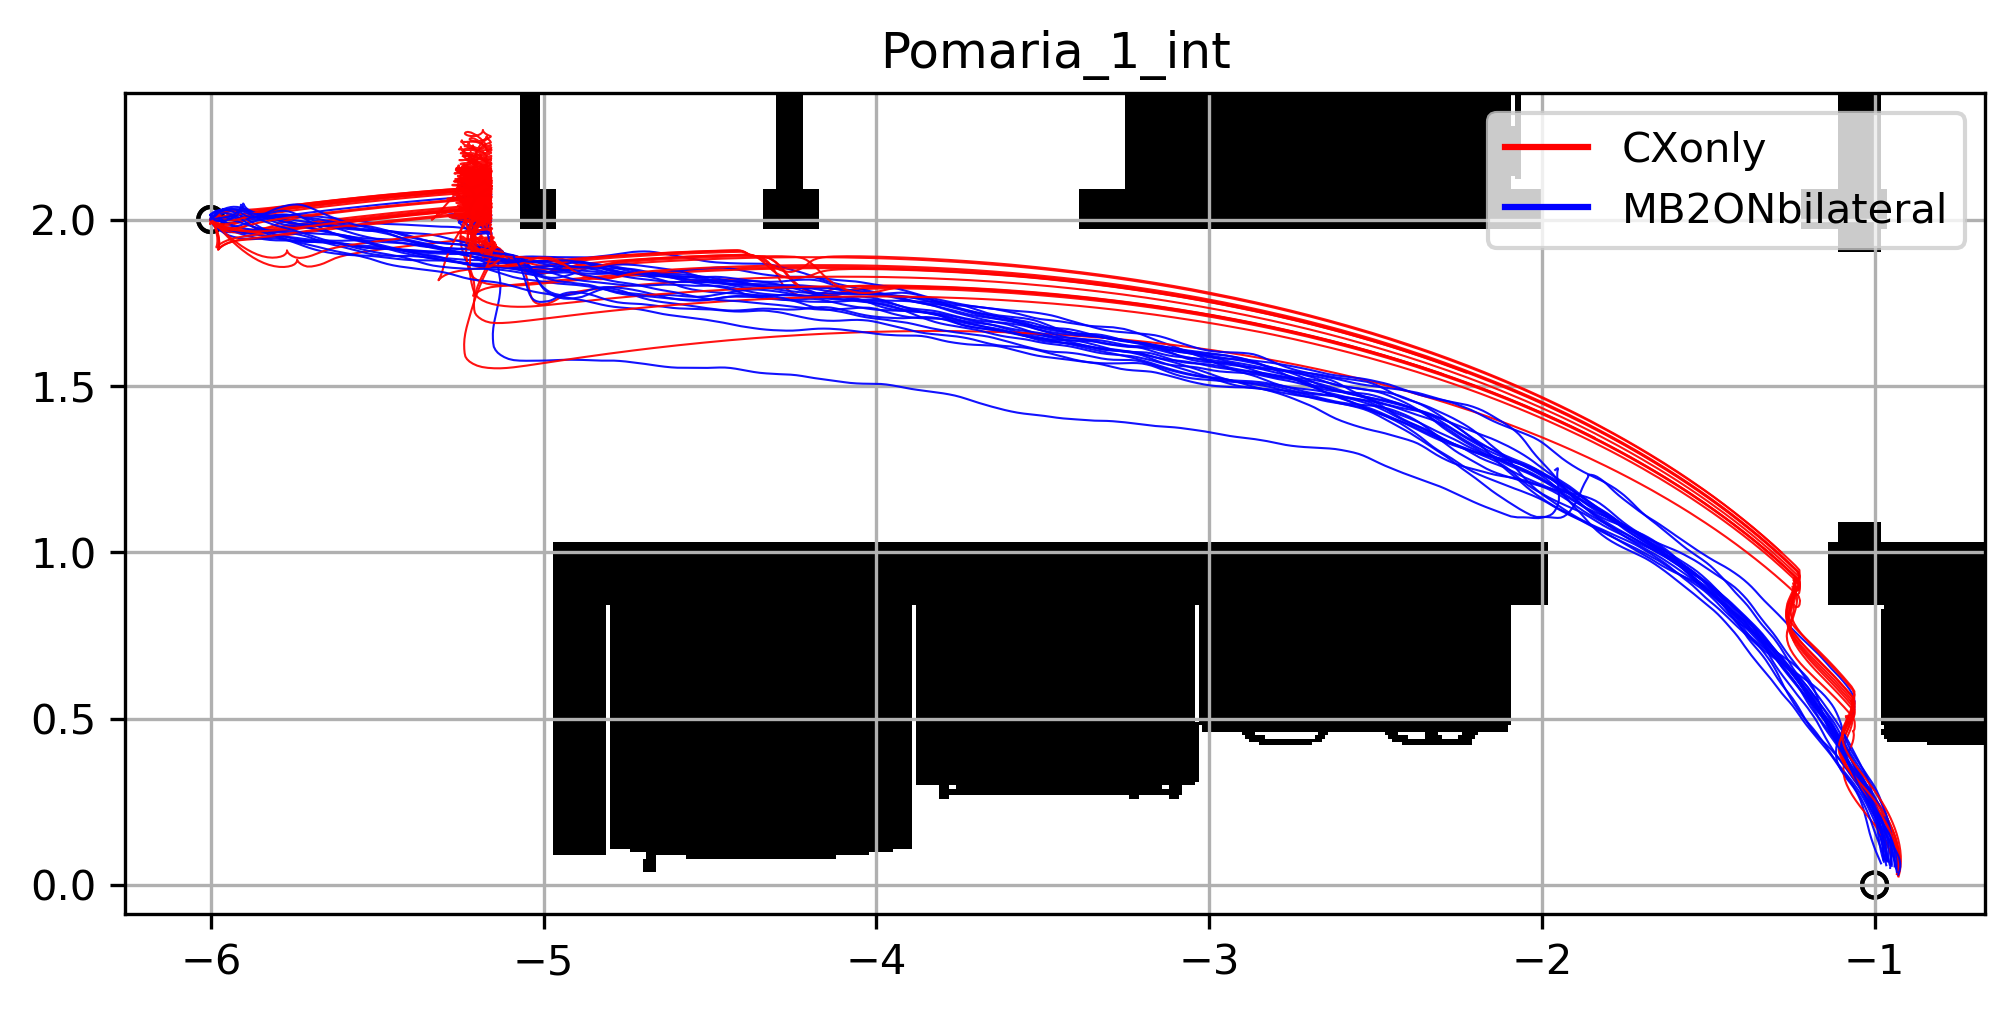

In [7]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
bias = 0.5

for trial in range(n_trial):
    for model_name, color in zip(model_names, ls_color):
        x, y = allbiasdata[bias][model_name]['x'][trial], allbiasdata[bias][model_name]['y'][trial]
        if trial >= -45:
            ax.plot(x, y, 
                    c=color, alpha=0.93, #(trial + 1 + n_trial) / (n_trial * 2),
                    lw=.5)
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
    
for model_name, color in zip(model_names, ls_color):
    ax.plot([], [], c=color, label=model_name)
    ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')

ax.set_aspect('equal')
ax.legend()

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
ax.grid()
ax.set_title(scene_name)

Text(0, 0.5, 'SPL (%)')

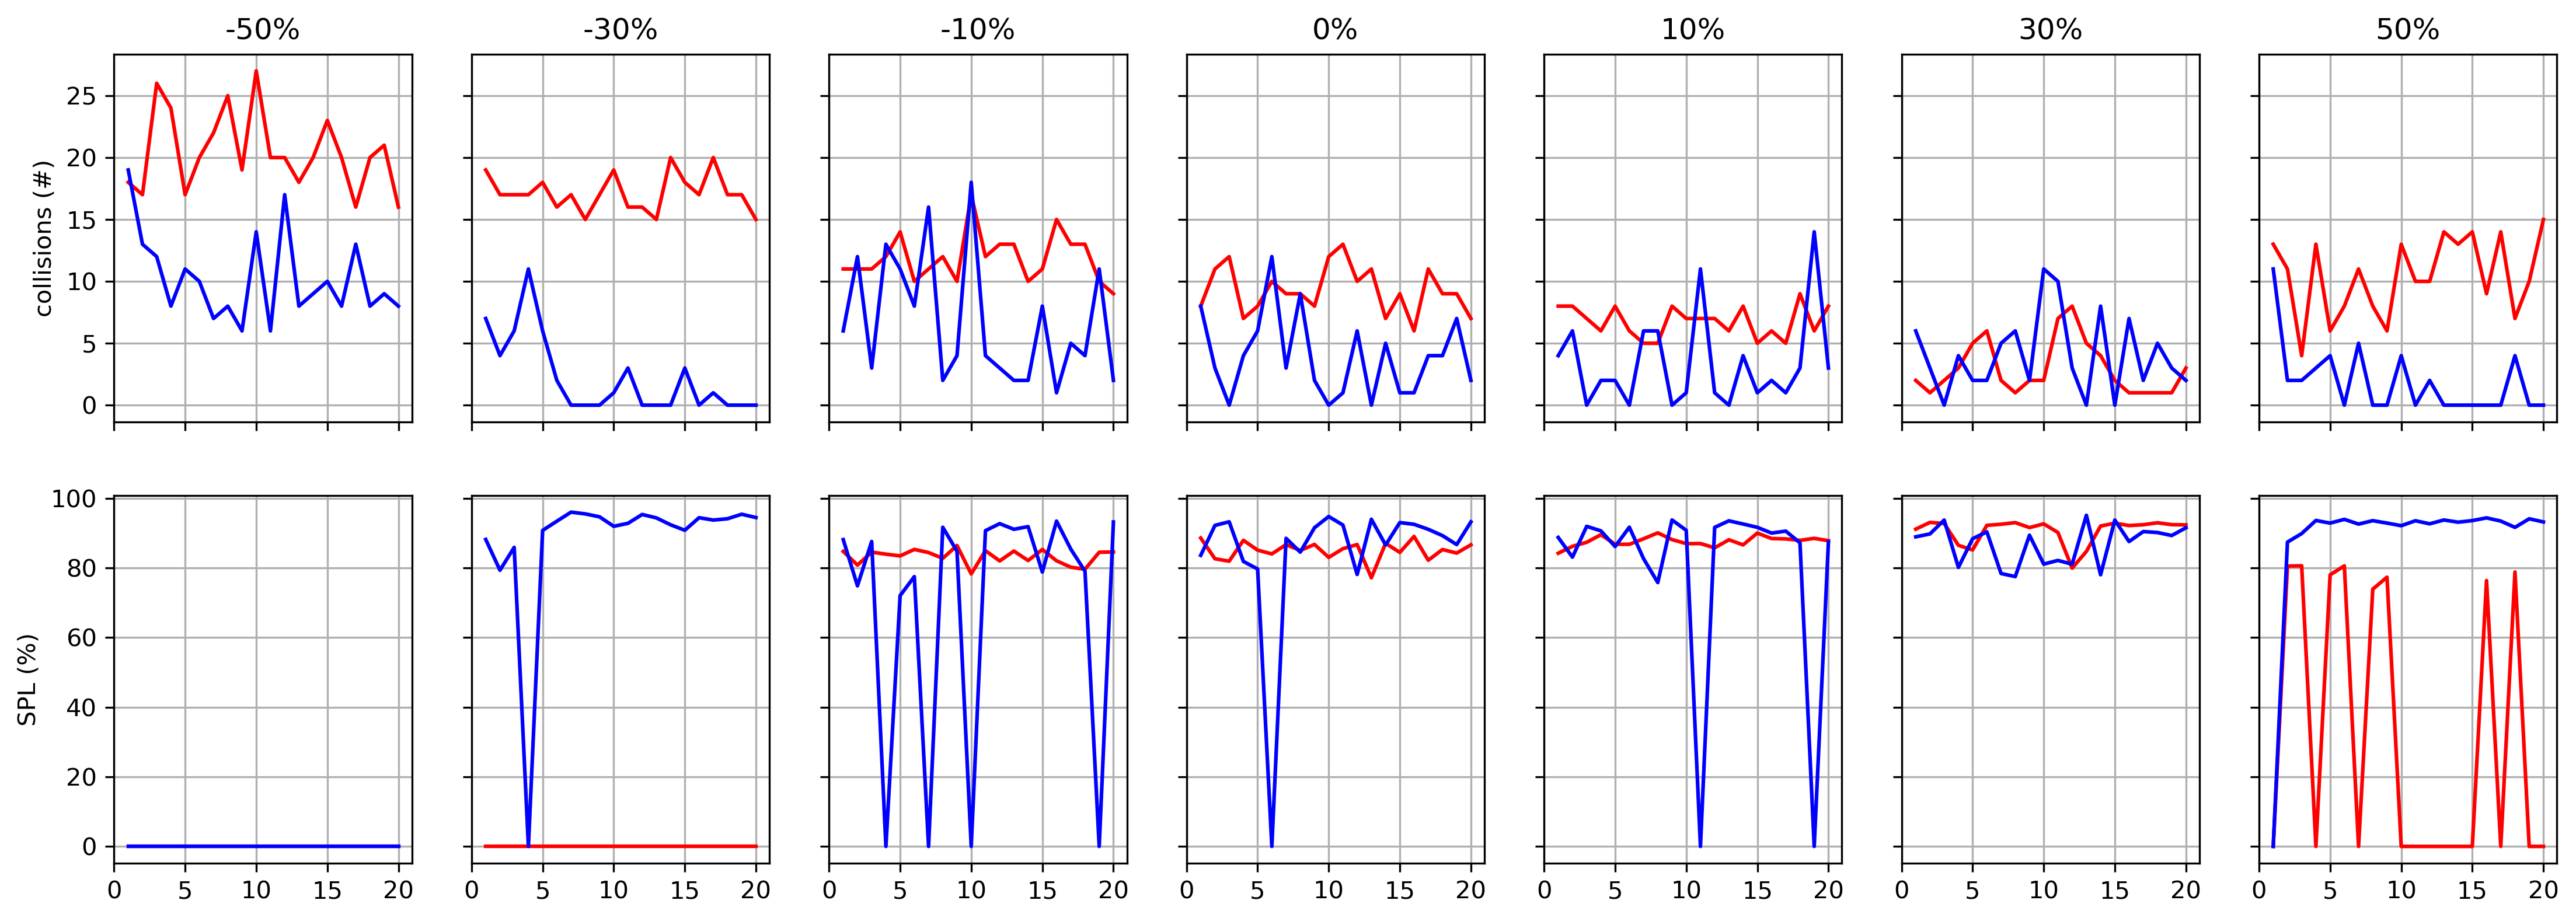

In [8]:
fig, axes = plt.subplots(2, 7, figsize=(18, 6), sharey='row', sharex=True, dpi=300)

data_col = []
data_spl = []

xx = np.arange(1, 21, 1)


for axcol, bias in zip(axes.T, bias_level):
    for model_name, c in zip(model_names, 'rb'):
        n_col = []
        m_spl = []
        xyf = [allbiasdata[bias][model_name][key] for key in 'xyf']
        for x, y, force in zip(*xyf):
            path = np.transpose([x, y])
            n_col.append(np.count_nonzero(force > 100))
            m_spl.append(spl(path, pos_start_goal[:, 1], shortest_dist) * 100)
        axcol[0].plot(xx, n_col, c=c)
        axcol[1].plot(xx, m_spl, c=c)
        
        data_col.append(n_col)
        data_spl.append(m_spl)
        
    axcol[0].set_title('{}%'.format(int(bias * 100)))
    
    for ax in axcol:
        ax.grid()
        ax.set_xticks(np.arange(0, 21, 5))
        
axes[0,0].set_ylabel('collisions (#)')
axes[1,0].set_ylabel('SPL (%)')

In [9]:
data_col_spl = [np.swapaxes(np.reshape(dat, (7, 2, -1)), 0, 1) for dat in (data_col, data_spl)]

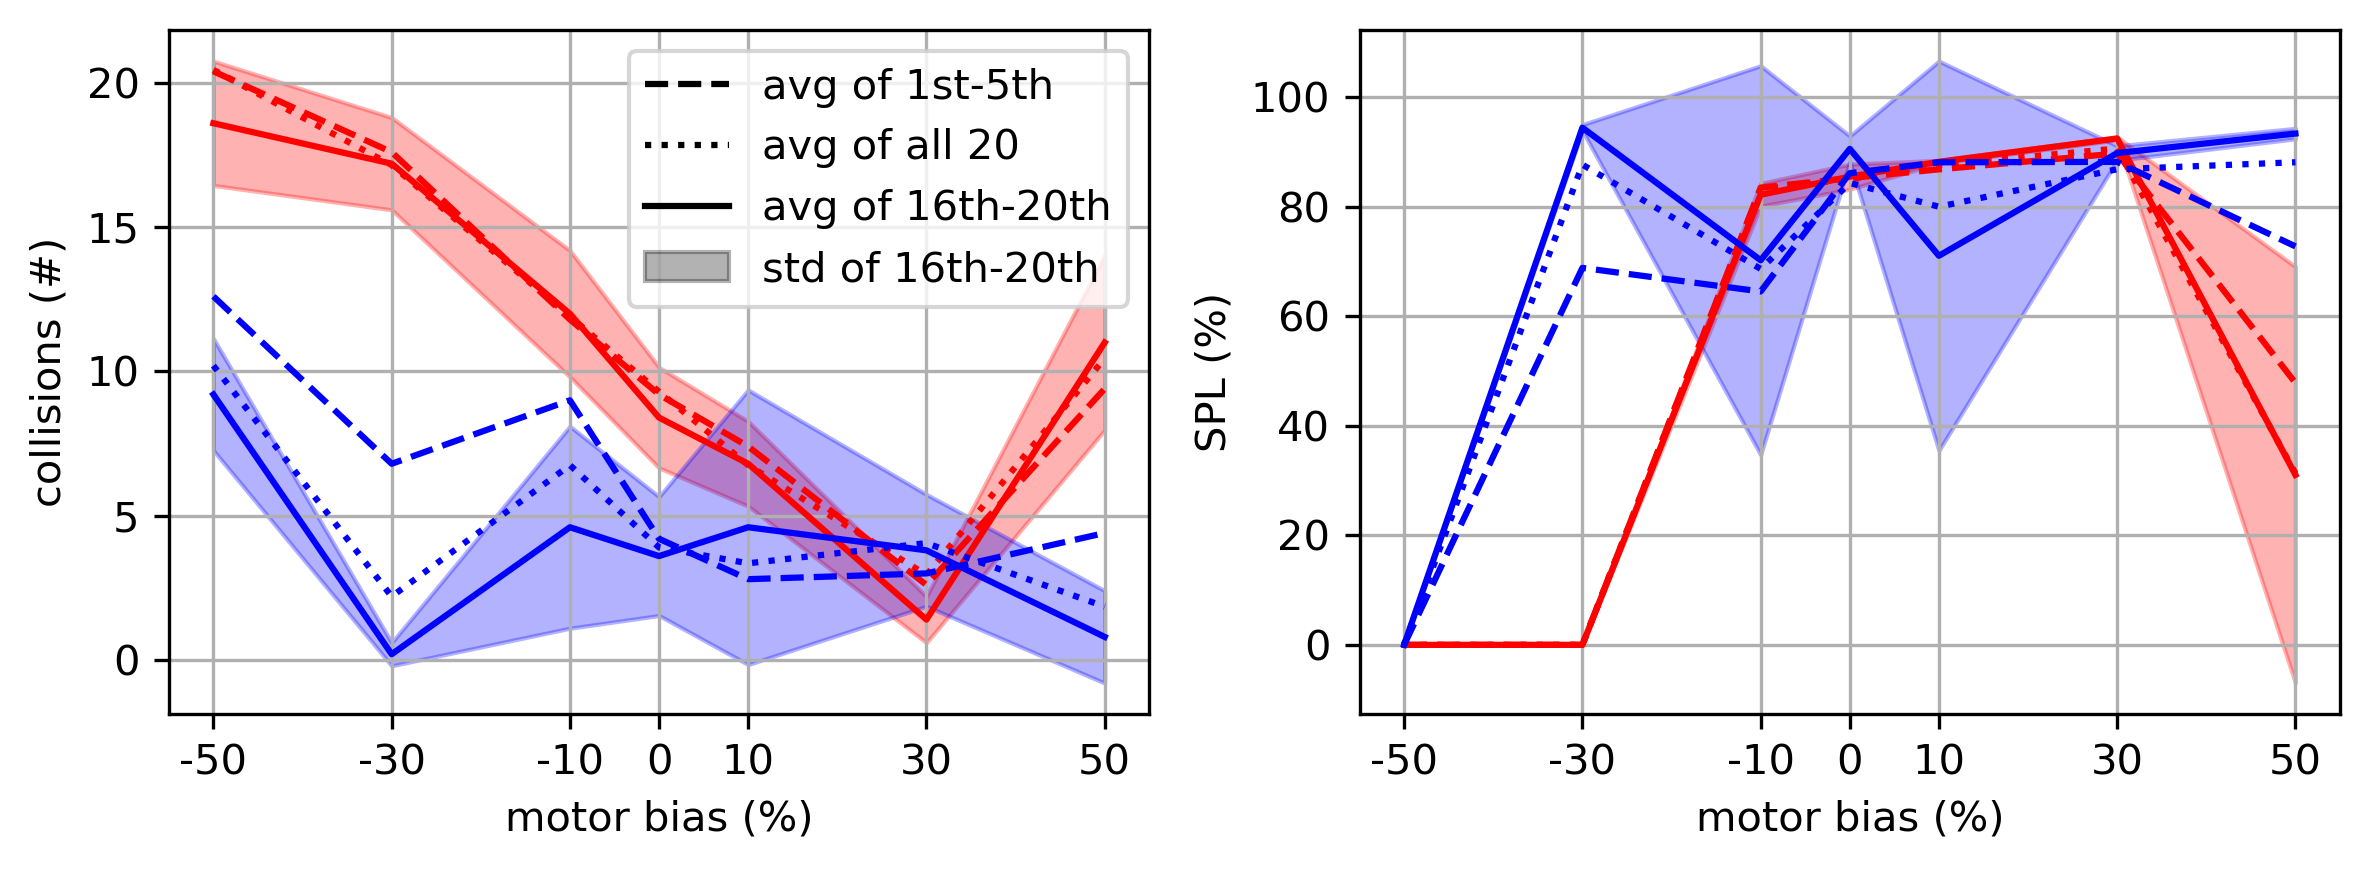

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=300, layout='tight')

for ax, dat in zip(axes, data_col_spl):
    for dc, c in zip(dat, 'rb'):
        yy = np.mean(dc[:, -5:], axis=-1)
        dy = np.std(dc[:, -5:], axis=-1)
        ax.plot(bias_level, yy, c=c)
        ax.fill_between(bias_level, yy - dy, yy + dy, alpha=0.3, color=c)

        ax.plot(bias_level, np.mean(dc[:, :5], axis=-1), c=c, ls='dashed')
        ax.plot(bias_level, np.mean(dc, axis=-1), c=c, ls='dotted')
    
for ax, yl in zip(axes, ('collisions (#)', 'SPL (%)')):
    ax.grid()
    ax.set_ylabel(yl)
    ax.set_xticks(bias_level, np.multiply(bias_level, 100).astype(int))
    ax.set_xlabel('motor bias (%)')

ax = axes[0]
for ls, lb in zip(['dashed', 'dotted', 'solid'], ['avg of 1st-5th', 'avg of all 20', 'avg of 16th-20th']):
    ax.plot([], [], label=lb, ls=ls, color='k')
ax.fill_between([], [], [], label='std of 16th-20th', color='k', alpha=0.3)
ax.legend()

In [11]:
type(data_col_spl)

list

In [12]:
import json
with open('igibson_bias.json', 'w') as f:
    json.dump(np.array(data_col_spl).tolist(), f)

In [13]:
np.shape(data_col_spl)

(2, 2, 7, 20)

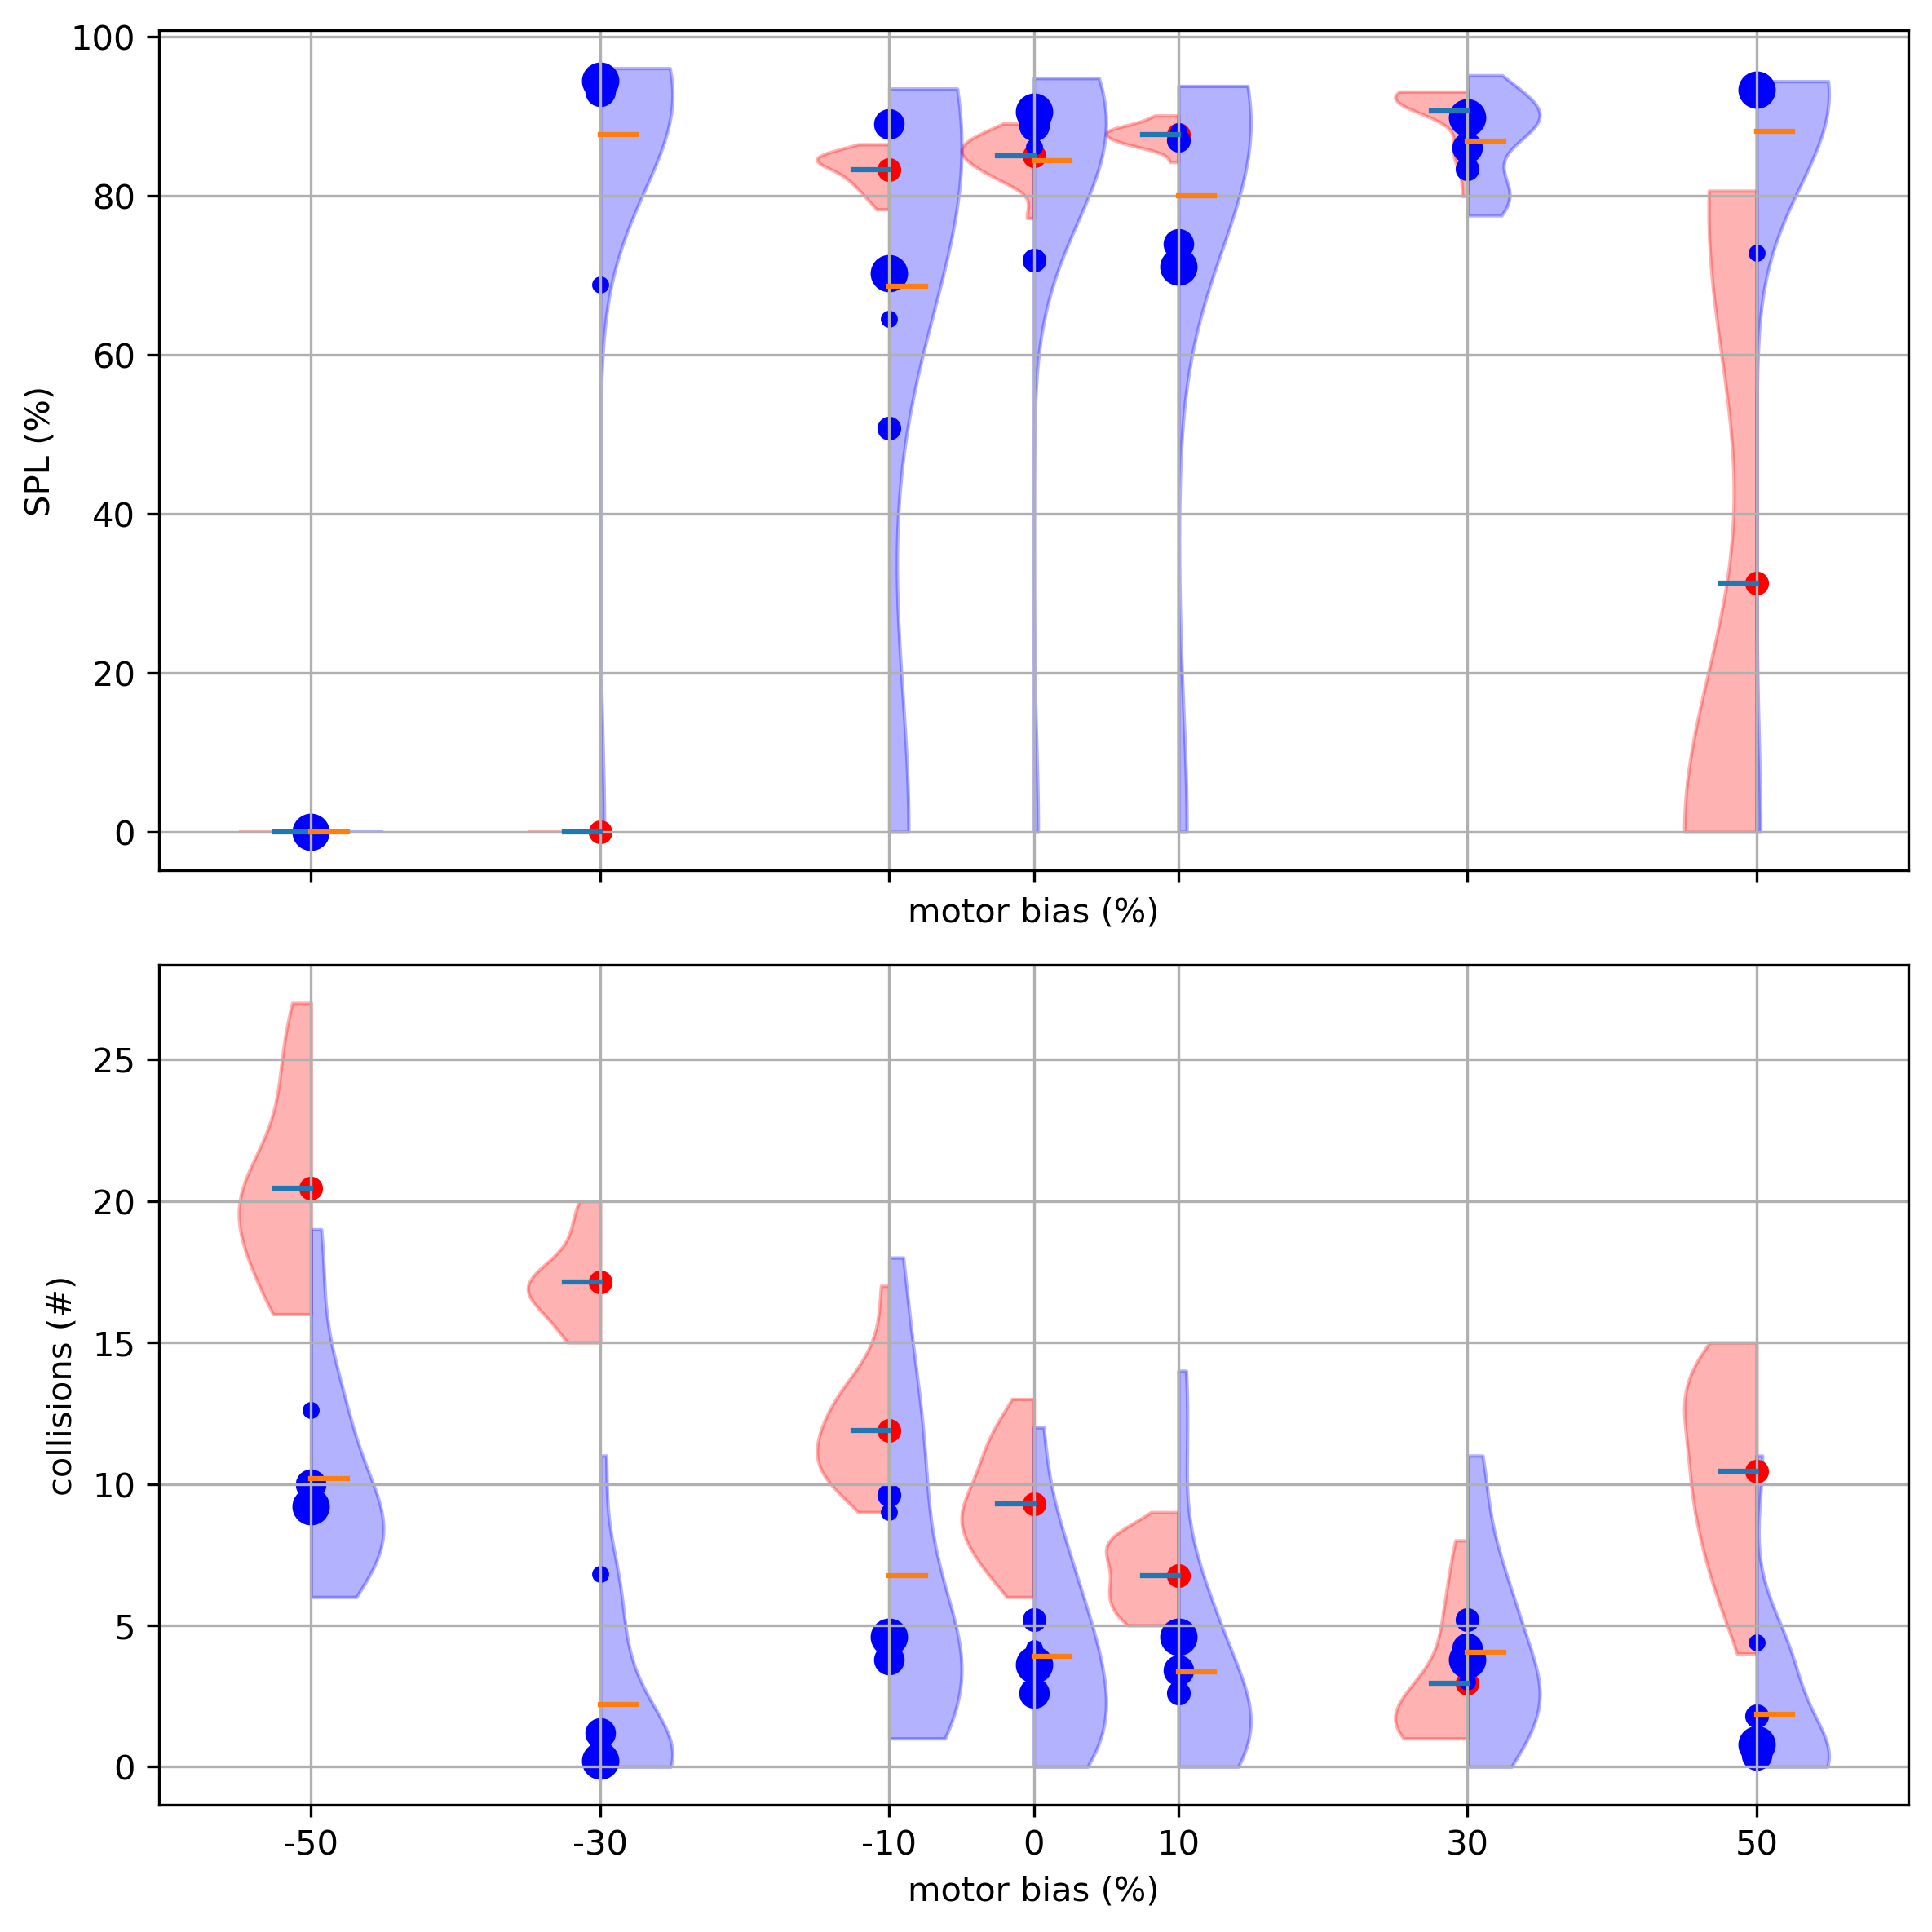

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8), dpi=300, layout='tight', sharex=True)

xx = np.array(bias_level)
for ax, dat in zip(np.flip(axes), data_col_spl):
    for dc, c, half in zip(dat, 'rb', ['low', 'high']):
        parts=ax.violinplot(dc.T, positions=xx, 
                                  widths=0.1,
                            side = half,
                         showextrema=False, showmeans=True
                         )
        for pc in parts['bodies']:
            pc.set_facecolor(c)
            pc.set_edgecolor(c)
            pc.set_alpha(0.3)        
    
    ax.scatter(xx, np.mean(dat[0], axis=-1), c='r', alpha=1)
    for a, lo in zip([0.4, 0.6, 0.8, 1], [0, 5, 10, 15]):
        yy = np.mean(dat[1, :, lo:lo+5], axis=-1)
        ax.scatter(xx, yy, c='b', s=(a*10)**2)
    
for ax, yl in zip(np.flip(axes), ('collisions (#)', 'SPL (%)')):
    ax.grid()
    ax.set_ylabel(yl)
    ax.set_xlabel('motor bias (%)')
    ax.set_xticks(bias_level, np.multiply(bias_level, 100).astype(int))

# ax = axes[1]
# for ls, lb in zip(['dashed', 'dotted', 'solid'], ['avg of 1st-5th', 'avg of all 20', 'avg of 16th-20th']):
#     ax.plot([], [], label=lb, ls=ls, color='k')
# ax.fill_between([], [], [], label='std of 16th-20th', color='k', alpha=0.3)
# ax.legend()

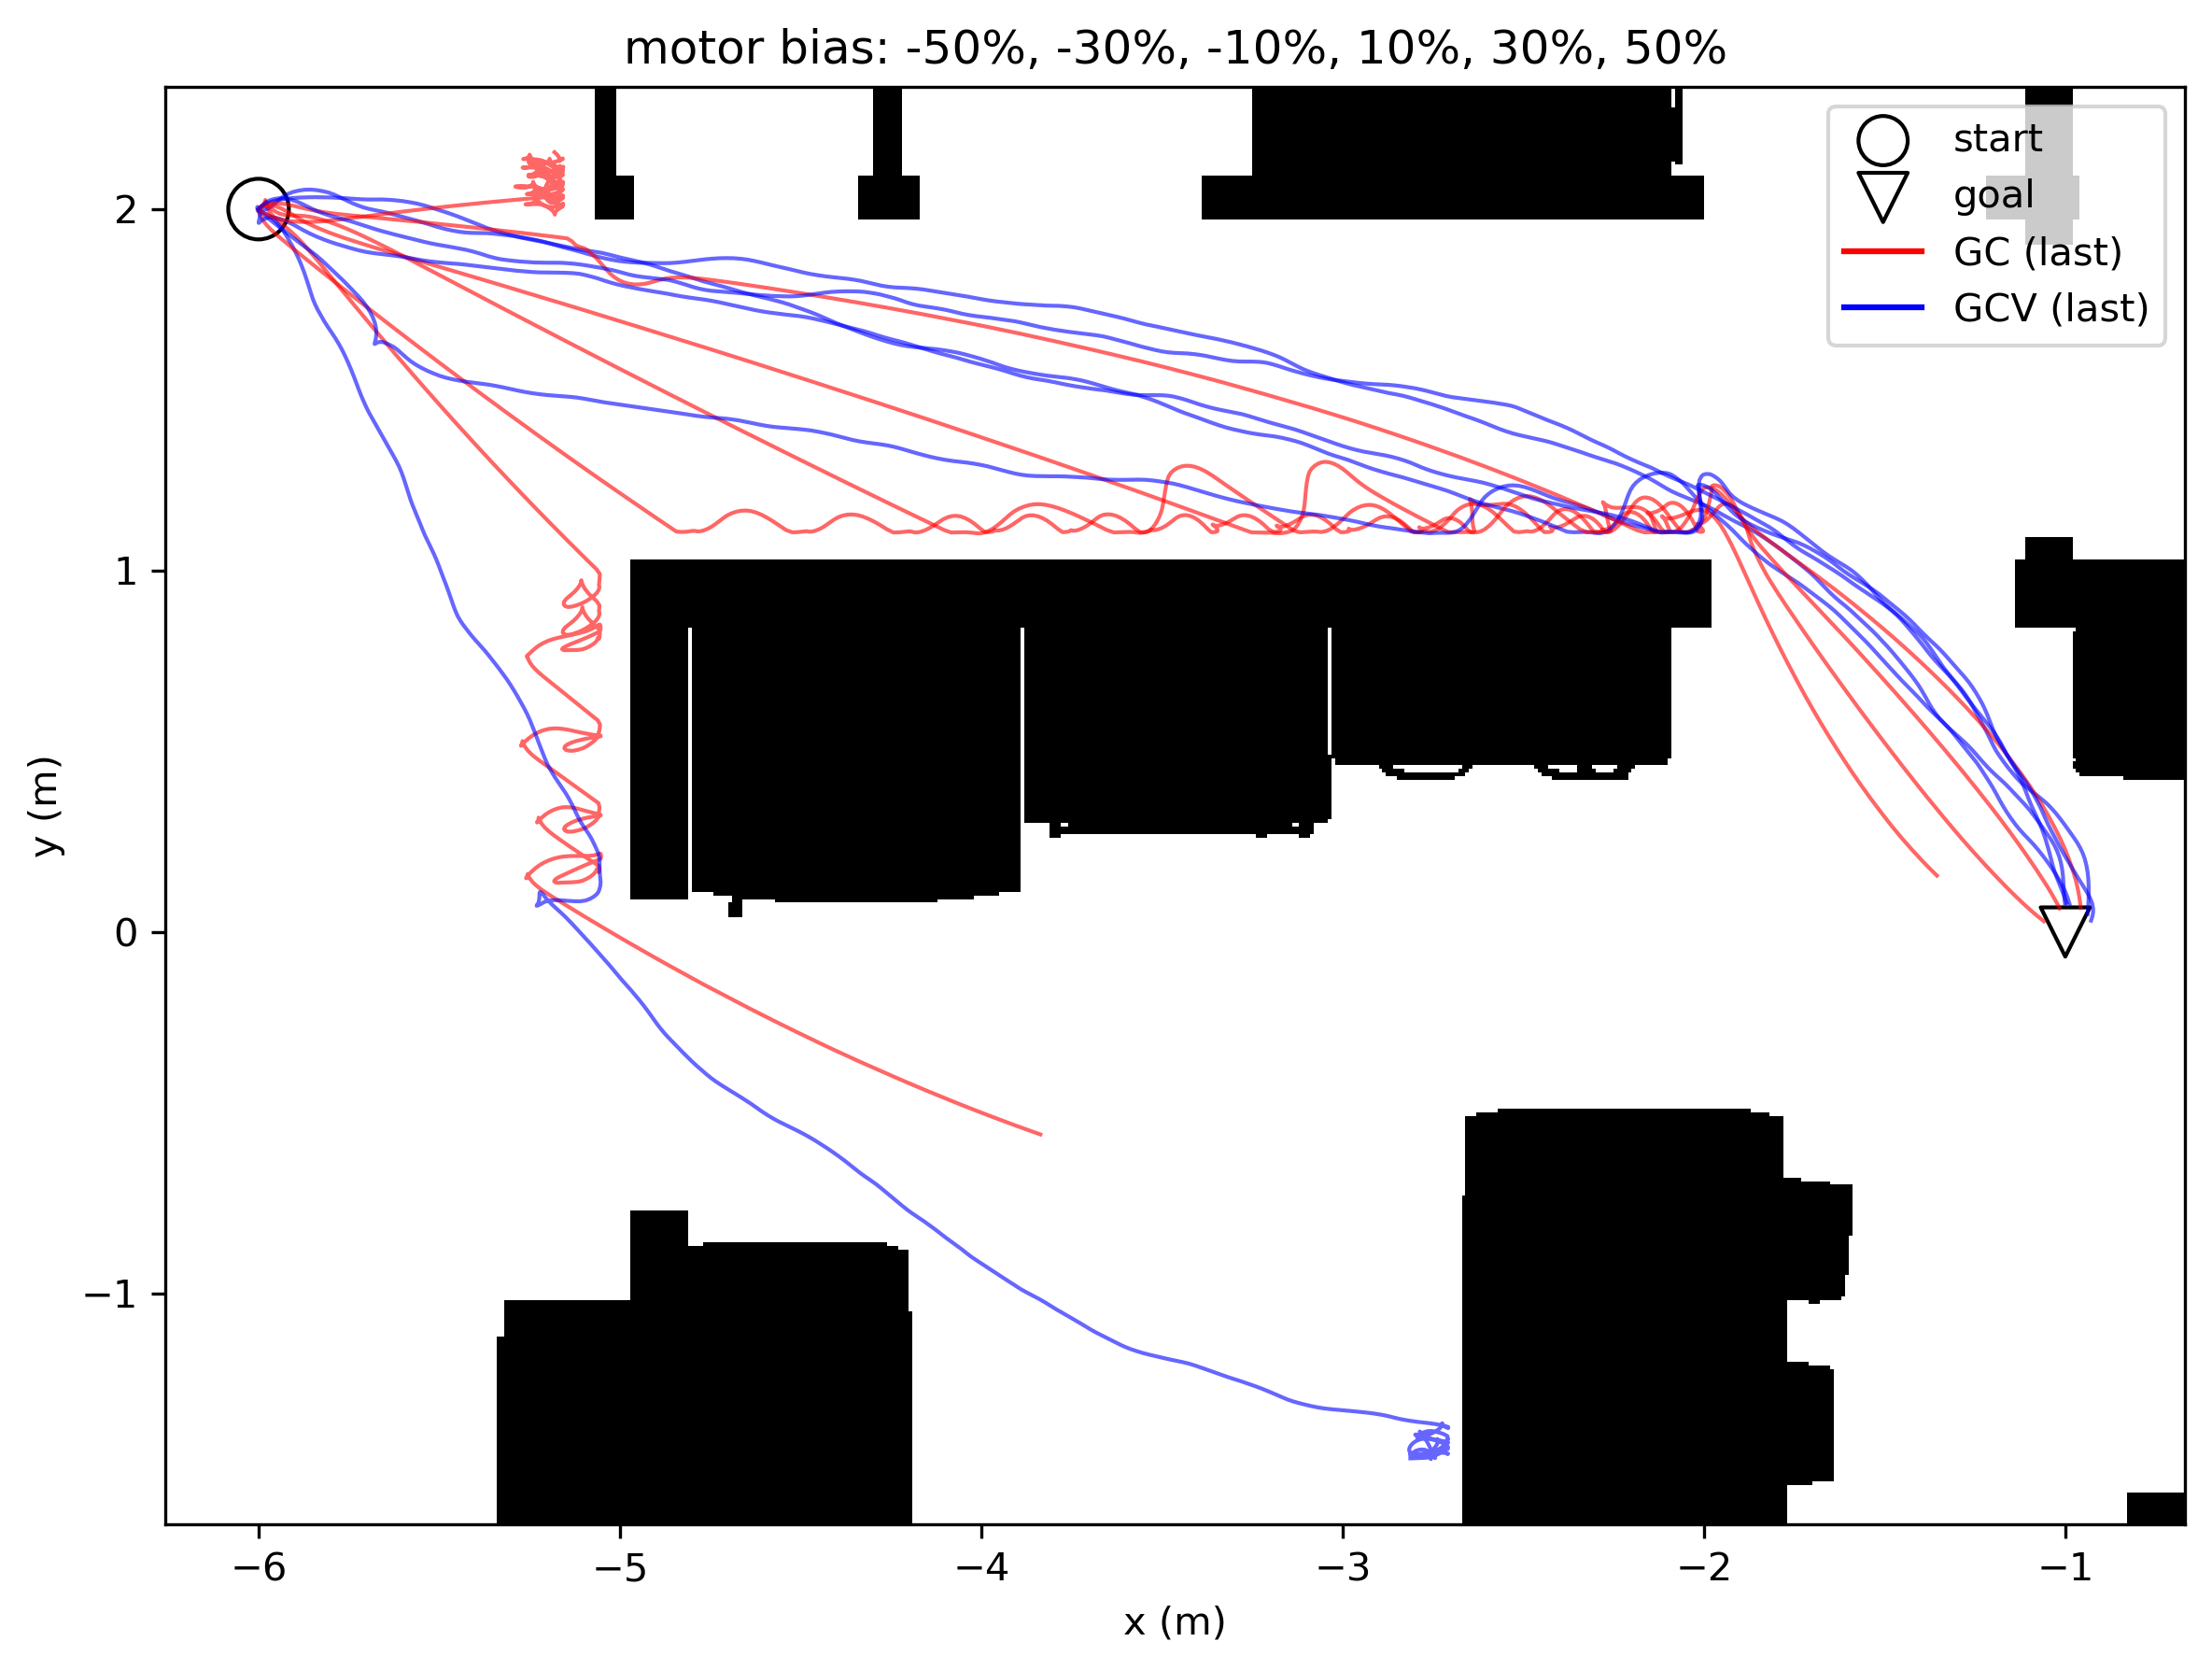

In [15]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300, layout='tight')



for bias in np.array(bias_level)[[0,1,2,4,5,6]]:
    for model_name, color, aa in zip(model_names, ls_color, [0.3, 0.4]):
        for trial in range(n_trial):
            x, y = allbiasdata[bias][model_name]['x'][trial], allbiasdata[bias][model_name]['y'][trial]
            if trial == 19:
                ax.plot(x, y, c=color, ls='solid', lw=1, alpha=0.6)
            else:
                pass
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()    



body = plt.Circle(pos_start_goal[:, 0], 0.559 / 2 * 0.3, edgecolor='k', facecolor='none')
ax.add_patch(body)
ax.scatter([], [], edgecolor='k', facecolor='none', marker='o', s=160, label='start')

ax.scatter(*pos_start_goal[:, 1], edgecolor='k', facecolor='none', marker='v', s=160, label='goal')


for mn, color in zip(['GC (last)', 'GCV (last)'], ls_color):
    ax.plot([], [], c=color, label=mn)

    
    
ax.set_aspect('equal')
ax.legend()

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
# ax.grid()
ax.set_title('motor bias: -50%, -30%, -10%, 10%, 30%, 50%')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_yticks([-1,0,1,2])




In [16]:
import matplotlib as mpl
mpl.rcParams.update({
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

plt.rcParams['lines.markersize'] = 7

In [ ]:
fig, ax = plt.subplots(figsize=(3.5, 3), dpi=300, layout='tight')


for trial in range(n_trial):
    for model_name, color, aa in zip(model_names, ls_color, [0.2, 0.4]):
        x, y = allbiasdata[bias][model_name]['x'][trial], allbiasdata[bias][model_name]['y'][trial]
        if trial == 0:
            ax.plot(x, y, c=color, ls='dashed', lw=1, alpha=0.6)
        elif trial == 19:
            ax.plot(x, y, c=color, ls='solid', lw=1, alpha=0.6)
        else:
            ax.plot(x, y, ls='dotted',
                    c=color, alpha=aa, 
                    lw=1)

    xlim, ylim = ax.get_xlim(), ax.get_ylim()    



body = plt.Circle(pos_start_goal[:, 0], 0.559 / 2 * 0.3, edgecolor='k', facecolor='none')
ax.add_patch(body)
ax.scatter([], [], edgecolor='k', facecolor='none', marker='o', s=60, label='start')
ax.plot([], [], c='k', ls='dashed', label='first')
ax.scatter(*pos_start_goal[:, 1], edgecolor='k', facecolor='none', marker='v', s=60, label='goal')
ax.plot([], [], c='k', ls='dotted', label='2nd-19th')
ax.plot([], [], c='b', label='Full')
ax.plot([], [], c='k', ls='solid', label='last')
ax.plot([], [], c='r', label='A2')

# for lb, ls in zip(['first', '2nd-19th', 'last'], ['dashed', 'dotted', 'solid']):
#     ax.plot([], [], c='k', ls=ls, label=lb)

# for mn, color in zip(['A2', 'Excess'], ls_color):
#     ax.plot([], [], c=color, label=mn)




ax.set_aspect('equal')
fig.legend(bbox_to_anchor=[0.15, 0.1], loc='center left', ncol=4)

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
# ax.grid()
ax.set_title('motor bias: 50%, motor noise: 5%')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_yticks([0,1,2])


from matplotlib.patches import Rectangle
xlims = -5.3, -4.9
ylims = 1.6, 2.3
rect = Rectangle([xlims[0], ylims[0]], xlims[1]-xlims[0], ylims[1]-ylims[0], edgecolor='k', facecolor='none', ls='dashed')
ax.add_patch(rect)

plt.savefig("igibson-example-path.pdf", format="pdf", bbox_inches="tight", dpi=300)

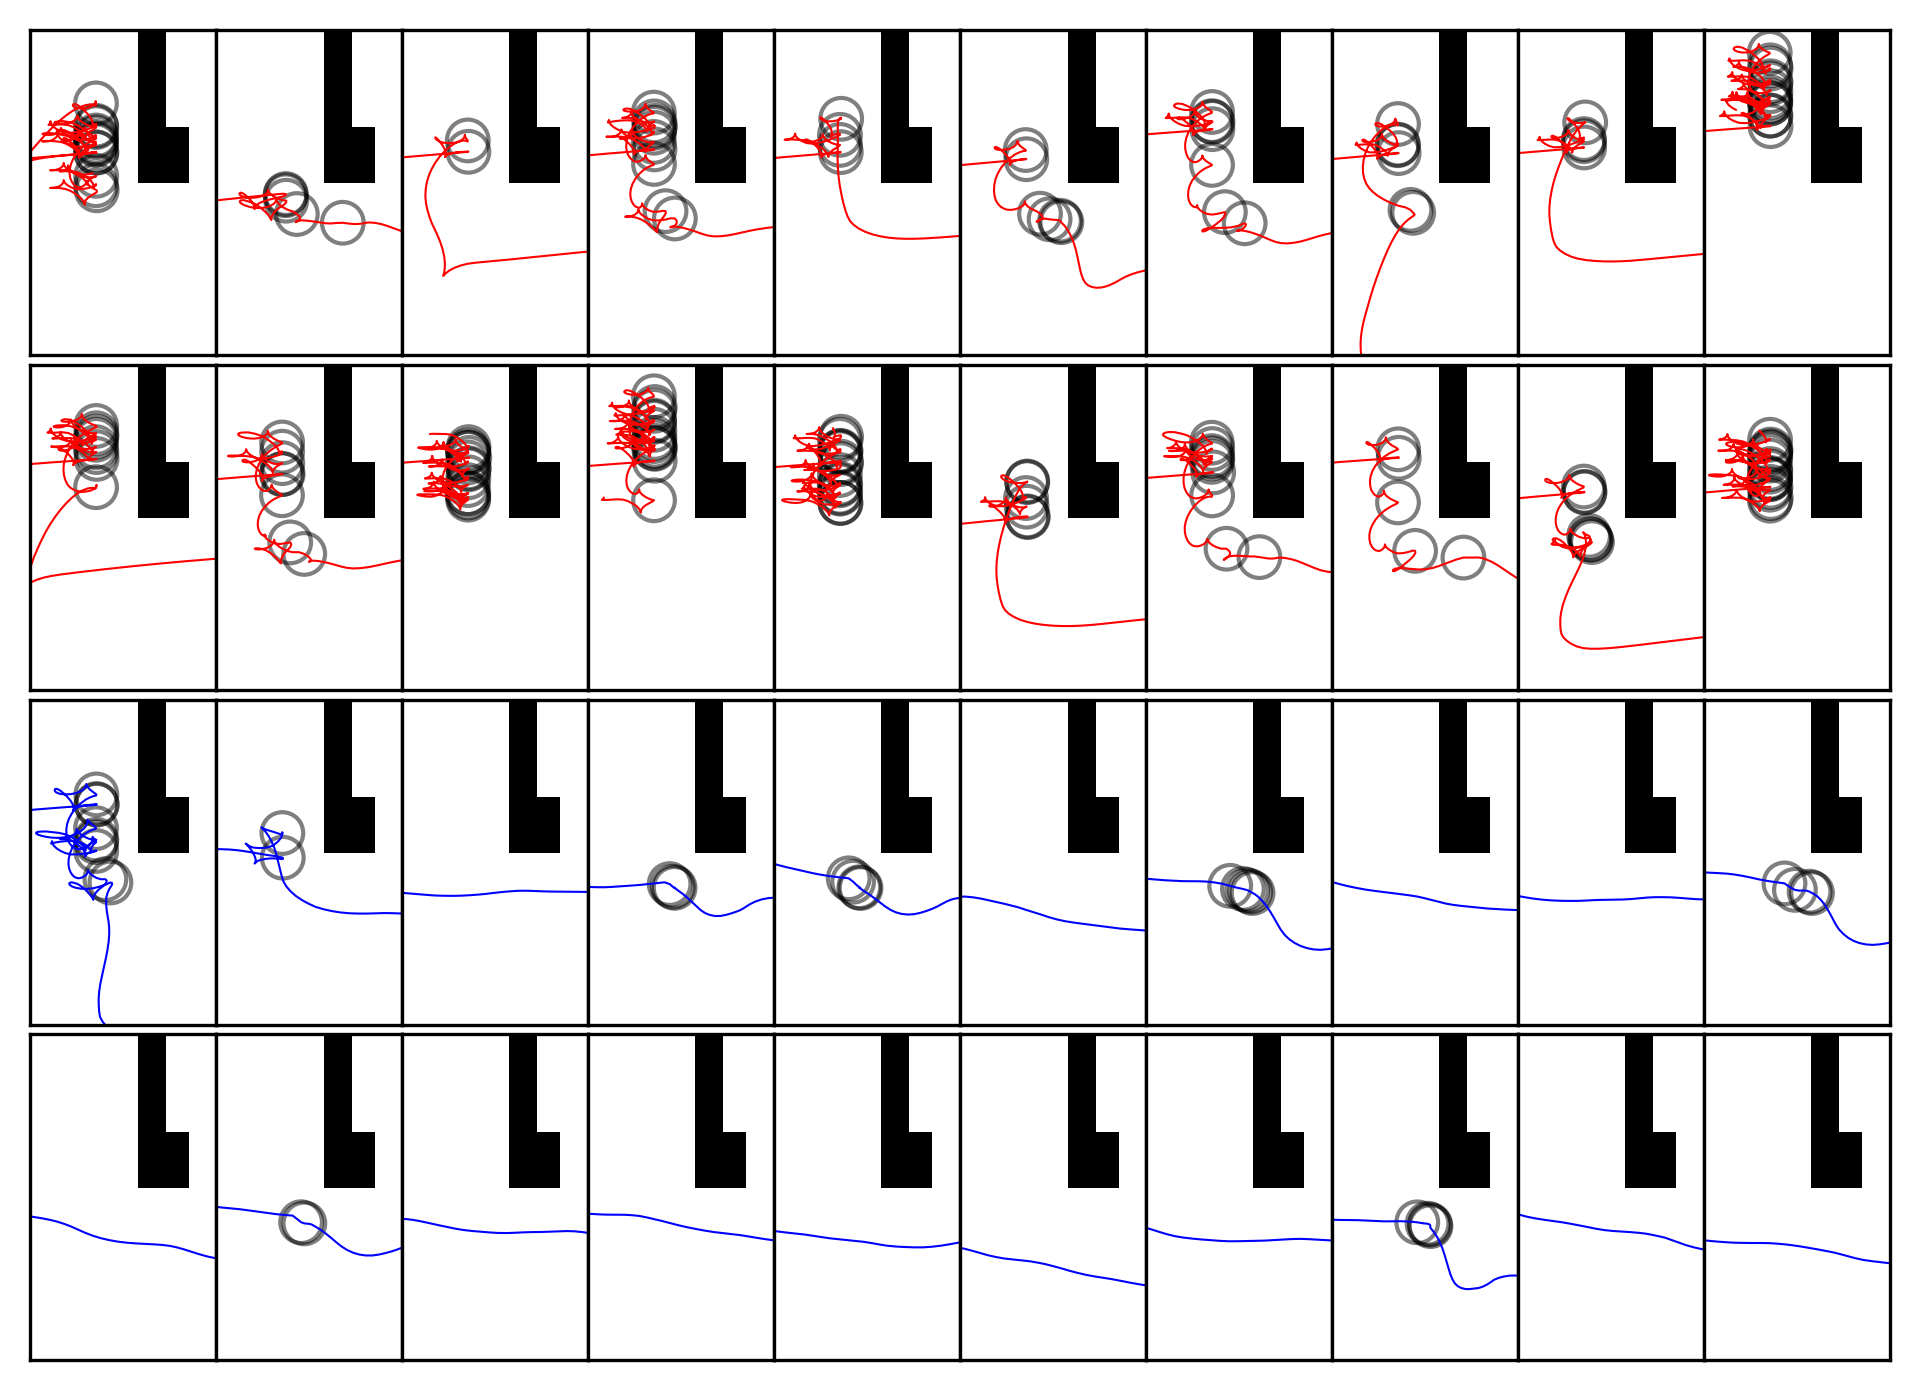

In [18]:
fig, axes = plt.subplots(4, 10, figsize=(8,5.8), dpi=300, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0, wspace=0)



for model_name, color, axrow in zip(model_names, ls_color, axes.reshape(2,-1)):
    for trial, ax in zip(np.arange(20), axrow):
        x, y = allbiasdata[bias][model_name]['x'][trial], allbiasdata[bias][model_name]['y'][trial]
        colid = allbiasdata[bias][model_name]['f'][trial] > 100
        ax.plot(x, y, c=color, ls='solid', lw=0.5)
        ax.scatter(x[colid], y[colid], edgecolor='k', facecolor='none', s=100, alpha=0.5)
        ax.set_xlim(*xlims)
        ax.set_ylim(*ylims)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        draw_floorplan(ax, floorplan, 0.01)
